<a href="https://colab.research.google.com/github/taras-ivanyk/Data_Analysis/blob/main/Lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [ ]:
ПІБ = 'Іваник Тарас Юрійович'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-34'      # напр. 'КН-31'
ВАРІАНТ = 8     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [ ]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Іваник Тарас Юрійович, ШІ-34, варіант 8
ваш потік:                   P>5
ваша пара для графіка 3:     швидкість вітру та густина вітру
ваш агрегат для етапу 4:     максимум
ваше додаткове питання:      Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [ ]:
# ВАШ КОД
pd.read_excel(ФАЙЛ)

,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7220,NaN,2017,9,21,2335,58017,84900,21.9,0.361,0.202,0.084,0.0717,0.0475,143000,32900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7221,NaN,2017,9,21,2340,58017,85200,14.1,0.343,0.309,0.118,0.0679,0.0328,143000,32100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7222,NaN,2017,9,21,2345,58017,85500,27.1,0.465,0.237,0.106,0.0593,0.0251,140000,32500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7223,NaN,2017,9,21,2350,58017,85800,23.7,0.36,0.205,0.127,0.091,0.0363,140000,32700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Відповідь 1.1:** Звичайне читання дало дивний результат, бо аркуш `Sheet1` не є однією акуратною таблицею з одним рядком заголовків. У ньому поруч розміщено кілька різних таблиць, а над ними є службові текстові рядки. Тому `pandas` сприймає перший непорожній рядок як заголовок для всього аркуша, через що назви стовпців виходять випадковими, а типи даних у багатьох стовпцях стають `object`.

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [ ]:
RAW = pd.read_excel(ФАЙЛ, header=None)
print('Розмір RAW:', RAW.shape)
RAW.head(30)

Розмір RAW: (7226, 32)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [ ]:
filled = RAW.notna().sum()
print(filled)

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64


**Відповідь 1.3:** В аркуші видно **три окремі таблиці**, вставлені поруч. За структурою та методичними вказівками вони займають такі стовпці аркуша:

- **Таблиця A:** B–O
- **Таблиця B:** Q–T
- **Таблиця C:** Y–AF

Між ними є порожні службові стовпці, тому при читанні всього аркуша як однієї таблиці структура ламається.

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [ ]:
print('Службові рядки над таблицею A:')
display(RAW.iloc[:12, 1:15])

print('Службові рядки над таблицею B:')
display(RAW.iloc[:12, 16:20])

print('Службові рядки над таблицею C:')
display(RAW.iloc[:12, 24:32])

Службові рядки над таблицею A:


,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Службові рядки над таблицею B:


,16,17,18,19
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN


Службові рядки над таблицею C:


,24,25,26,27,28,29,30,31
0,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | супутник GOES-15 | потоки частинок, одиниці потоку з підписів у службовому описі |
| B | добовий радіопотік F10.7 | solar flux units / sfu |
| C | дані про сонячний вітер (швидкість і густина) | швидкість — км/с, густина — частинок/см³ |

---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [ ]:
# Таблиця A: стовпці B:O -> індекси 1:15
A_raw = RAW.iloc[:, 1:15].copy()

# Таблиця B: стовпці Q:T -> індекси 16:20
B_raw = RAW.iloc[:, 16:20].copy()

# Таблиця C: стовпці Y:AF -> індекси 24:32
C_raw = RAW.iloc[:, 24:32].copy()

print('A_raw shape:', A_raw.shape)
print('B_raw shape:', B_raw.shape)
print('C_raw shape:', C_raw.shape)

print('\nПерші 15 рядків A_raw:')
display(A_raw.head(15))

print('\nПерші 15 рядків B_raw:')
display(B_raw.head(15))

print('\nПерші 15 рядків C_raw:')
display(C_raw.head(15))

# ---------- A ----------
A = A_raw.copy()
A = A.iloc[6:].reset_index(drop=True)   # якщо не спрацює, посуньте 6 на 7/8 після перегляду head
A.columns = ['yy', 'mm', 'dd', 'hhmm',
             'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100',
             'E>0.8', 'E>2.0', 'extra1', 'extra2']

for c in A.columns:
    A[c] = pd.to_numeric(A[c], errors='coerce')

A = A.dropna(how='all').reset_index(drop=True)

# ---------- B ----------
B = B_raw.copy()
B = B.iloc[6:].reset_index(drop=True)
B.columns = ['yy', 'mm', 'dd', 'F10.7']

for c in B.columns:
    B[c] = pd.to_numeric(B[c], errors='coerce')

B = B.dropna(how='all').reset_index(drop=True)

# ---------- C ----------
C = C_raw.copy()
C = C.iloc[26:].reset_index(drop=True)   # пропускаємо службові рядки до початку числових даних
C.columns = [f'c{i}' for i in range(C.shape[1])]

for c in C.columns:
    C[c] = pd.to_numeric(C[c], errors='coerce')

C = C.dropna(how='all').reset_index(drop=True)

# правильні стовпці
C = C.rename(columns={
    'c2': 'yy',
    'c3': 'mm',
    'c4': 'dd',
    'c0': 'hh',
    'c6': 'швидкість вітру',
    'c7': 'густина вітру'
})

C = C[['yy', 'mm', 'dd', 'hh', 'швидкість вітру', 'густина вітру']]

print(C.head())
print(C.describe())
print('len(C)=', len(C))

# тимчасово лишаємо тільки потрібні стовпці
A = A[['yy', 'mm', 'dd', 'hhmm', 'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']]
B = B[['yy', 'mm', 'dd', 'F10.7']]


A_raw shape: (7226, 14)
B_raw shape: (7226, 4)
C_raw shape: (7226, 8)

Перші 15 рядків A_raw:


,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Перші 15 рядків B_raw:


,16,17,18,19
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN



Перші 15 рядків C_raw:


,24,25,26,27,28,29,30,31
0,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


     yy   mm    dd   hh  швидкість вітру  густина вітру
0  17.0  8.0  28.0  0.0            285.0            3.0
1  17.0  8.0  28.0  1.0            305.0            3.4
2  17.0  8.0  28.0  2.0            309.0            1.7
3  17.0  8.0  28.0  3.0            304.0            2.0
4  17.0  8.0  28.0  4.0            302.0            2.3
          yy          mm          dd          hh  швидкість вітру  густина вітру
count  601.0  601.000000  601.000000  601.000000       601.000000     601.000000
mean    17.0    8.840266   13.973378   11.480865       506.547421       2.907654
std      0.0    0.366664    8.781000    6.938063       125.073291       2.637873
min     17.0    8.000000    1.000000    0.000000        -1.000000      -1.000000
25%     17.0    9.000000    7.000000    5.000000       447.000000       1.800000
50%     17.0    9.000000   13.000000   11.000000       517.000000       2.400000
75%     17.0    9.000000   19.000000   17.000000       584.000000       3.400000
max     17.0    

### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [ ]:
# A: рік може бути записаний як 17, тому додаємо 2000
A['year'] = np.where(A['yy'] < 100, 2000 + A['yy'], A['yy'])
A['hh'] = (A['hhmm'] // 100).astype('Int64')
A['mi'] = (A['hhmm'] % 100).astype('Int64')
A['ts'] = pd.to_datetime(dict(year=A['year'], month=A['mm'], day=A['dd'],
                              hour=A['hh'], minute=A['mi']), errors='coerce')

# B
B['year'] = np.where(B['yy'] < 100, 2000 + B['yy'], B['yy'])
B['ts'] = pd.to_datetime(dict(year=B['year'], month=B['mm'], day=B['dd']), errors='coerce')

# C
C['year'] = np.where(C['yy'] < 100, 2000 + C['yy'], C['yy'])
C['ts'] = pd.to_datetime(dict(year=C['year'], month=C['mm'], day=C['dd'],
                              hour=C['hh']), errors='coerce')

print('A:', A['ts'].min(), '->', A['ts'].max())
print('B:', B['ts'].min(), '->', B['ts'].max())
print('C:', C['ts'].min(), '->', C['ts'].max())


A: 2017-08-28 00:00:00 -> 2017-09-21 23:55:00
B: 2017-08-28 00:00:00 -> 2017-09-21 00:00:00
C: 2017-08-28 00:00:00 -> 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [ ]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [ ]:
for name, df in [('A', A), ('B', B), ('C', C)]:
    print('='*80)
    print(name)
    print('shape:', df.shape)
    print('\ndtypes:')
    print(df.dtypes)
    print('\nПропуски:')
    print(df.isna().sum())
    print('\nПовні дублікати:', df.duplicated().sum())
    print('\ndescribe():')
    display(df.describe(include='all'))

A
shape: (7200, 16)

dtypes:
yy              float64
mm              float64
dd              float64
hhmm            float64
P>1             float64
P>5             float64
P>10            float64
P>30            float64
P>50            float64
P>100           float64
E>0.8           float64
E>2.0           float64
year            float64
hh                Int64
mi                Int64
ts       datetime64[ns]
dtype: object

Пропуски:
yy       0
mm       0
dd       0
hhmm     0
P>1      0
P>5      0
P>10     3
P>30     3
P>50     3
P>100    3
E>0.8    3
E>2.0    3
year     0
hh       0
mi       0
ts       0
dtype: int64

Повні дублікати: 0

describe():


,yy,mm,dd,hhmm,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,year,hh,mi,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7200.0,7200.0,7200.0,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,2017.0,11.5,27.5,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,2017.0,0.0,0.0,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,2017.0,5.75,13.75,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,2017.0,11.5,27.5,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,2017.0,17.25,41.25,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,2017.0,23.0,55.0,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,0.0,6.922667,17.261461,NaN


B
shape: (25, 6)

dtypes:
yy              float64
mm              float64
dd              float64
F10.7           float64
year            float64
ts       datetime64[ns]
dtype: object

Пропуски:
yy       0
mm       0
dd       0
F10.7    0
year     0
ts       0
dtype: int64

Повні дублікати: 0

describe():


,yy,mm,dd,F10.7,year,ts
count,25.0,25.000000,25.000000,25.000000,25.0,25
mean,2017.0,8.840000,13.960000,92.680000,2017.0,2017-09-09 00:00:00
min,2017.0,8.000000,1.000000,71.000000,2017.0,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,74.000000,2017.0,2017-09-03 00:00:00
50%,2017.0,9.000000,13.000000,84.000000,2017.0,2017-09-09 00:00:00
75%,2017.0,9.000000,19.000000,107.000000,2017.0,2017-09-15 00:00:00
max,2017.0,9.000000,31.000000,140.000000,2017.0,2017-09-21 00:00:00
std,0.0,0.374166,8.955817,22.206831,0.0,NaN


C
shape: (601, 8)

dtypes:
yy                        float64
mm                        float64
dd                        float64
hh                        float64
швидкість вітру           float64
густина вітру             float64
year                      float64
ts                 datetime64[ns]
dtype: object

Пропуски:
yy                   0
mm                   0
dd                   0
hh                   0
швидкість вітру      0
густина вітру        0
year                 0
ts                 301
dtype: int64

Повні дублікати: 0

describe():


,yy,mm,dd,hh,швидкість вітру,густина вітру,year,ts
count,601.000000,601.000000,601.0,601.000000,601.000000,601.000000,601.000000,300
mean,11.480865,11.480865,17.0,8.840266,13.973378,11.480865,2011.480865,2007-01-01 14:50:24
min,0.000000,0.000000,17.0,8.000000,1.000000,0.000000,2000.000000,2001-01-17 08:00:00
25%,5.000000,5.000000,17.0,9.000000,7.000000,5.000000,2005.000000,2004-01-09 02:15:00
50%,11.000000,11.000000,17.0,9.000000,13.000000,11.000000,2011.000000,2006-12-31 20:30:00
75%,17.000000,17.000000,17.0,9.000000,19.000000,17.000000,2017.000000,2009-12-25 02:45:00
max,23.000000,23.000000,17.0,9.000000,31.000000,23.000000,2023.000000,2012-12-17 09:00:00
std,6.938063,6.938063,0.0,0.366664,8.781000,6.938063,6.938063,NaN


### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [ ]:
print('До заміни:')
print('швидкість вітру -> min =', C['швидкість вітру'].min(), ', mean =', C['швидкість вітру'].mean())
print('густина вітру   -> min =', C['густина вітру'].min(), ', mean =', C['густина вітру'].mean())

neg_speed = (C['швидкість вітру'] < 0).sum()
neg_density = (C['густина вітру'] < 0).sum()

print('\nКількість від’ємних значень:')
print('швидкість вітру:', neg_speed)
print('густина вітру:', neg_density)

C.loc[C['швидкість вітру'] < 0, 'швидкість вітру'] = np.nan
C.loc[C['густина вітру'] < 0, 'густина вітру'] = np.nan

print('\nПісля заміни:')
print('швидкість вітру -> min =', C['швидкість вітру'].min(), ', mean =', C['швидкість вітру'].mean())
print('густина вітру   -> min =', C['густина вітру'].min(), ', mean =', C['густина вітру'].mean())

До заміни:
швидкість вітру -> min = 1.0 , mean = 13.973377703826955
густина вітру   -> min = 0.0 , mean = 11.480865224625624

Кількість від’ємних значень:
швидкість вітру: 0
густина вітру: 0

Після заміни:
швидкість вітру -> min = 1.0 , mean = 13.973377703826955
густина вітру   -> min = 0.0 , mean = 11.480865224625624


**Відповідь 3.2:** Від’ємні значення в таблиці C не є реальними фізичними вимірюваннями, бо ні швидкість, ні густина сонячного вітру не можуть бути меншими за нуль. У службовому описі такі значення позначають відсутні або некоректні дані. Через них мінімум ставав штучно від’ємним, а середнє зміщувалося вниз, тому перед подальшим аналізом їх потрібно замінити на `NaN`.

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [ ]:
display(A.describe())
print(A.columns.tolist())

,yy,mm,dd,hhmm,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,year,hh,mi,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7200.0,7200.0,7200.0,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,2017.0,11.5,27.5,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,2017.0,0.0,0.0,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,2017.0,5.75,13.75,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,2017.0,11.5,27.5,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,2017.0,17.25,41.25,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,2017.0,23.0,55.0,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,0.0,6.922667,17.261461,NaN


['yy', 'mm', 'dd', 'hhmm', 'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0', 'year', 'hh', 'mi', 'ts']


**Відповідь 3.3:** Безглуздо обчислювати середнє для стовпців, які кодують **дату й час**, а не результат вимірювання: наприклад, `yy`, `mm`, `dd`, `hhmm` (або похідні від них). Це технічні координати спостереження, а не фізичні величини. Середнє між годинами `0005`, `0010` і `2355` не має фізичного змісту так само, як і «середній день місяця» в межах такого файлу.

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [ ]:
flow_cols = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

A_hourly = (
    A.set_index('ts')[flow_cols]
     .resample('1H')
     .agg(['mean', 'max'])
)

A_hourly.columns = [f'{col}_{"avg" if agg=="mean" else "max"}' for col, agg in A_hourly.columns]
A_hourly = A_hourly.reset_index()

display(A_hourly.head())
print(A_hourly.shape)

/tmp/ipykernel_3403/2713150422.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample('1H')


,ts,P>1_avg,P>1_max,P>5_avg,P>5_max,P>10_avg,P>10_max,P>30_avg,P>30_max,P>50_avg,P>50_max,P>100_avg,P>100_max,E>0.8_avg,E>0.8_max,E>2.0_avg,E>2.0_max
0,2017-08-28 00:00:00,57993.0,57993.0,1650.0,3300.0,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793
1,2017-08-28 01:00:00,57993.0,57993.0,5250.0,6900.0,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471
2,2017-08-28 02:00:00,57993.0,57993.0,8850.0,10500.0,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595
3,2017-08-28 03:00:00,57993.0,57993.0,12450.0,14100.0,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818
4,2017-08-28 04:00:00,57993.0,57993.0,16050.0,17700.0,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694


(600, 17)


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

/tmp/ipykernel_3403/1702095838.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample('1H')


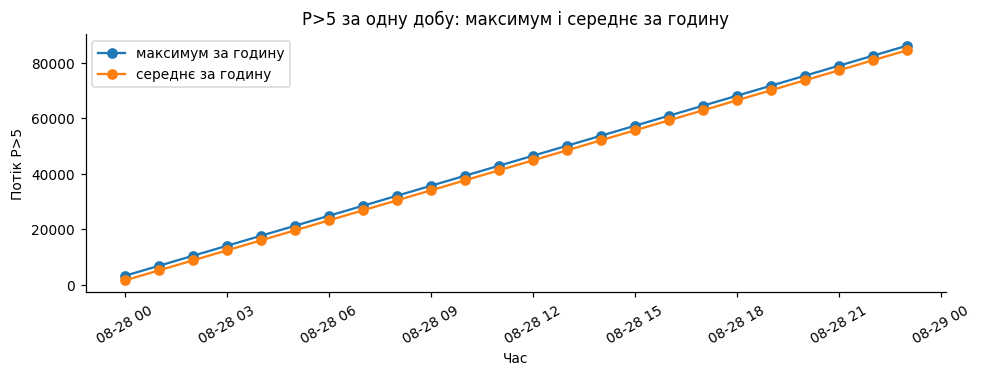

In [ ]:
# одна доба для прикладу
one_day = A[(A['ts'] >= A['ts'].min().floor('D')) & (A['ts'] < A['ts'].min().floor('D') + pd.Timedelta(days=1))].copy()

cmp = (
    one_day.set_index('ts')['P>5']
    .resample('1H')
    .agg(['max', 'mean'])
    .reset_index()
)

plt.figure(figsize=(9, 3.5))
plt.plot(cmp['ts'], cmp['max'], marker='o', label='максимум за годину')
plt.plot(cmp['ts'], cmp['mean'], marker='o', label='середнє за годину')
plt.xlabel('Час')
plt.ylabel('Потік P>5')
plt.title('P>5 за одну добу: максимум і середнє за годину')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

**Відповідь 4.2:** Крива максимуму за годину чутливіша до коротких піків, тому зазвичай лежить вище за середнє. Якщо протягом години є короткий, але дуже сильний сплеск, максимум покаже його одразу, а середнє частково «розмаже» цей сплеск. Різниця між ними стає особливо важливою тоді, коли дані мають рідкісні екстремальні викиди.

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [ ]:
# B: доба -> година
B_hourly = (
    B[['ts', 'F10.7']]
    .set_index('ts')
    .resample('1h')
    .ffill()
    .reset_index()
)

# C: уже година
C_hourly = C[['ts', 'швидкість вітру', 'густина вітру']].copy()

M_inner = A_hourly.merge(C_hourly, on='ts', how='inner').merge(B_hourly, on='ts', how='inner')
M_outer = A_hourly.merge(C_hourly, on='ts', how='outer').merge(B_hourly, on='ts', how='outer')

print('INNER:', M_inner.shape)
print('OUTER:', M_outer.shape)

M = M_outer.copy().sort_values('ts').reset_index(drop=True)

print('\nРозмір M:', M.shape)
display(M[M.isna().any(axis=1)])

INNER: (577, 20)
OUTER: (601, 20)

Розмір M: (601, 20)


,ts,P>1_avg,P>1_max,P>5_avg,P>5_max,P>10_avg,P>10_max,P>30_avg,P>30_max,P>50_avg,P>50_max,P>100_avg,P>100_max,E>0.8_avg,E>0.8_max,E>2.0_avg,E>2.0_max,швидкість вітру,густина вітру,F10.7
577,2017-09-21 01:00:00,58017.0,58017.0,5250.0,6900.0,37.408333,56.30,0.268250,0.375,0.196667,0.335,0.116075,0.255,0.078192,0.1600,0.039483,0.0737,453.0,1.9,NaN
578,2017-09-21 02:00:00,58017.0,58017.0,8850.0,10500.0,36.841667,48.60,0.357250,0.774,0.229333,0.493,0.100842,0.154,0.071567,0.1290,0.038883,0.0737,453.0,1.9,NaN
579,2017-09-21 03:00:00,58017.0,58017.0,12450.0,14100.0,27.325000,39.80,0.380333,0.678,0.198750,0.411,0.093750,0.126,0.068617,0.0941,0.035458,0.0691,450.0,2.0,NaN
580,2017-09-21 04:00:00,58017.0,58017.0,16050.0,17700.0,16.550000,29.80,0.393250,0.591,0.196417,0.272,0.105617,0.185,0.071892,0.1110,0.031250,0.0420,452.0,2.1,NaN
581,2017-09-21 05:00:00,58017.0,58017.0,19650.0,21300.0,9.072500,15.20,0.533833,0.878,0.255917,0.422,0.103892,0.148,0.070758,0.0987,0.037933,0.0662,445.0,1.7,NaN
582,2017-09-21 06:00:00,58017.0,58017.0,23250.0,24900.0,9.601667,27.50,0.516583,0.943,0.246917,0.449,0.102425,0.132,0.072600,0.1010,0.036983,0.0761,443.0,1.5,NaN
583,2017-09-21 07:00:00,58017.0,58017.0,26850.0,28500.0,9.558333,12.80,0.433583,0.758,0.221333,0.384,0.088100,0.176,0.061750,0.1270,0.027700,0.0461,434.0,1.5,NaN
584,2017-09-21 08:00:00,58017.0,58017.0,30450.0,32100.0,8.098333,10.20,0.531000,0.921,0.258667,0.488,0.119367,0.304,0.083833,0.1990,0.036675,0.0601,431.0,1.7,NaN
585,2017-09-21 09:00:00,58017.0,58017.0,34050.0,35700.0,5.748333,8.17,0.470917,0.830,0.235917,0.508,0.119925,0.297,0.082808,0.1850,0.038842,0.0761,447.0,1.0,NaN
586,2017-09-21 10:00:00,58017.0,58017.0,37650.0,39300.0,6.768333,9.85,0.486333,0.980,0.254250,0.409,0.112050,0.233,0.076083,0.1610,0.035208,0.0620,438.0,1.0,NaN


**Відповідь 4.3:** Я обрав `outer`-об’єднання, бо воно зберігає всю часову сітку і дозволяє побачити, де саме в різних джерелах бракує значень. `inner` залишає тільки спільні часові точки, тому частина даних зникає. Для вхідного аналізу даних `outer` корисніший, бо пропуски тут є важливою частиною результату, а не просто технічною перешкодою.

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [ ]:
M['група'] = pd.cut(
    M['P>10_max'],
    bins=[-np.inf, 10, 1000, np.inf],
    labels=['тиха', 'активна', 'дуже активна'],
    right=False
)

print(M['група'].value_counts(dropna=False))

група
NaN             601
активна         387
дуже активна    120
тиха             93
Name: count, dtype: int64


In [ ]:
print('len(C) =', len(C))
print('C min ts =', C["ts"].min())
print('C max ts =', C["ts"].max())

flow_cols = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

A_hourly = (
    A.set_index('ts')[flow_cols]
     .resample('1H')
     .agg(['mean', 'max'])
)
A_hourly.columns = [f'{col}_{"avg" if agg=="mean" else "max"}' for col, agg in A_hourly.columns]
A_hourly = A_hourly.reset_index()

B_hourly = (
    B[['ts', 'F10.7']]
    .set_index('ts')
    .resample('1H')
    .ffill()
    .reset_index()
)

C_hourly = C[['ts', 'швидкість вітру', 'густина вітру']].copy()

print('A_hourly:', A_hourly.shape, A_hourly['ts'].min(), A_hourly['ts'].max())
print('B_hourly:', B_hourly.shape, B_hourly['ts'].min(), B_hourly['ts'].max())
print('C_hourly:', C_hourly.shape, C_hourly['ts'].min(), C_hourly['ts'].max())

M_inner = A_hourly.merge(C_hourly, on='ts', how='inner').merge(B_hourly, on='ts', how='inner')
M_outer = A_hourly.merge(C_hourly, on='ts', how='outer').merge(B_hourly, on='ts', how='outer')

print('INNER:', M_inner.shape)
print('OUTER:', M_outer.shape)

len(C) = 601
C min ts = 2017-08-28 00:00:00
C max ts = 2017-09-22 00:00:00
A_hourly: (600, 17) 2017-08-28 00:00:00 2017-09-21 23:00:00
B_hourly: (577, 2) 2017-08-28 00:00:00 2017-09-21 00:00:00
C_hourly: (601, 3) 2017-08-28 00:00:00 2017-09-22 00:00:00
INNER: (577, 20)
OUTER: (601, 20)


/tmp/ipykernel_3403/2904331463.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample('1H')
/tmp/ipykernel_3403/2904331463.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample('1H')


**Самоперевірка етапу 4.**

In [55]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 601 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

Середнє: 43050.0
Медіана: 43050.0


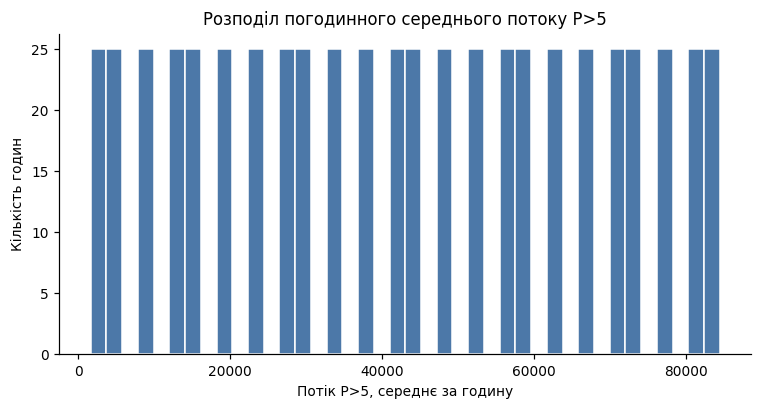

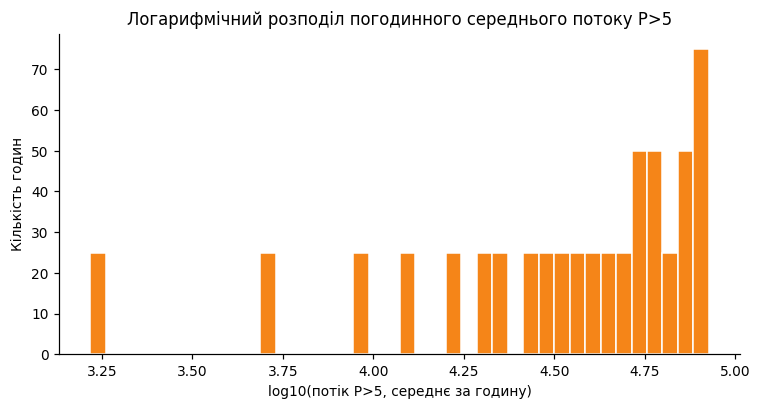

In [ ]:
col = 'P>5_avg'

mean_val = M[col].mean()
median_val = M[col].median()

print('Середнє:', mean_val)
print('Медіана:', median_val)

plt.figure(figsize=(7, 3.8))
plt.hist(M[col].dropna(), bins=40, color='#4c78a8', edgecolor='white')
plt.xlabel('Потік P>5, середнє за годину')
plt.ylabel('Кількість годин')
plt.title('Розподіл погодинного середнього потоку P>5')
plt.tight_layout()
plt.show()

positive = M[col][M[col] > 0].dropna()
if len(positive):
    plt.figure(figsize=(7, 3.8))
    plt.hist(np.log10(positive), bins=40, color='#f58518', edgecolor='white')
    plt.xlabel('log10(потік P>5, середнє за годину)')
    plt.ylabel('Кількість годин')
    plt.title('Логарифмічний розподіл погодинного середнього потоку P>5')
    plt.tight_layout()
    plt.show()

**Висновок:** Розподіл потоку `P>5` є різко скошеним вправо: більшість годин мають відносно малі значення, а невелика кількість годин дає дуже великі сплески, тому середнє виходить помітно більшим за медіану.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

/tmp/ipykernel_3403/684412504.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=['тиха', 'активна', 'дуже активна'], showfliers=True)


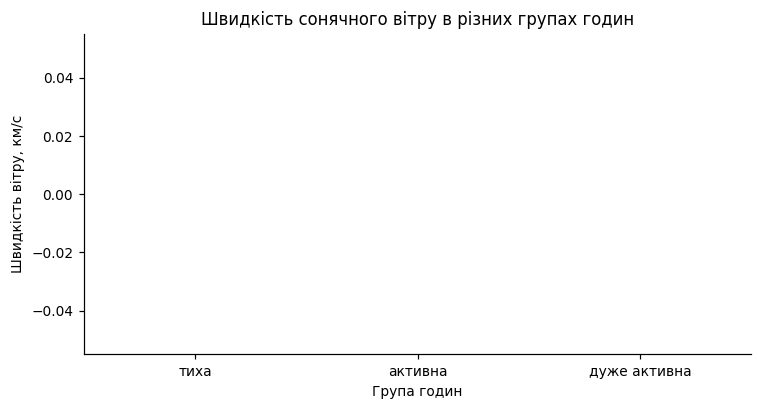

In [ ]:
box_data = [M.loc[M['група'] == g, 'швидкість вітру'].dropna() for g in ['тиха', 'активна', 'дуже активна']]

plt.figure(figsize=(7, 3.8))
plt.boxplot(box_data, labels=['тиха', 'активна', 'дуже активна'], showfliers=True)
plt.xlabel('Група годин')
plt.ylabel('Швидкість вітру, км/с')
plt.title('Швидкість сонячного вітру в різних групах годин')
plt.tight_layout()
plt.show()

**Висновок:** Діаграма розмаху показує, чи зсувається типовий рівень швидкості вітру між тихими, активними й дуже активними годинами; якщо медіани та міжквартильні інтервали сильно перекриваються, то вираженої різниці між групами немає.

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

Коефіцієнт кореляції: -0.002525208369851776


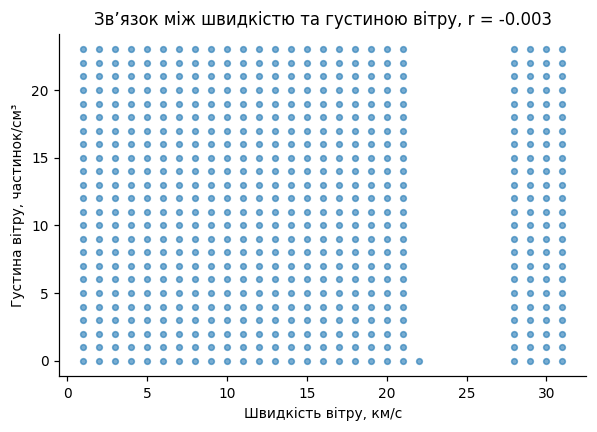

In [ ]:
pair = M[['швидкість вітру', 'густина вітру']].dropna()
corr = pair['швидкість вітру'].corr(pair['густина вітру'])

print('Коефіцієнт кореляції:', corr)

plt.figure(figsize=(5.5, 4))
plt.scatter(pair['швидкість вітру'], pair['густина вітру'], s=14, alpha=0.6)
plt.xlabel('Швидкість вітру, км/с')
plt.ylabel('Густина вітру, частинок/см³')
plt.title(f'Зв’язок між швидкістю та густиною вітру, r = {corr:.3f}')
plt.tight_layout()
plt.show()

**Висновок:** Зв’язок між швидкістю та густиною сонячного вітру потрібно оцінювати за хмарою точок і кореляцією; якщо точки сильно розкидані без чіткої форми, то лінійний зв’язок слабкий або відсутній.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

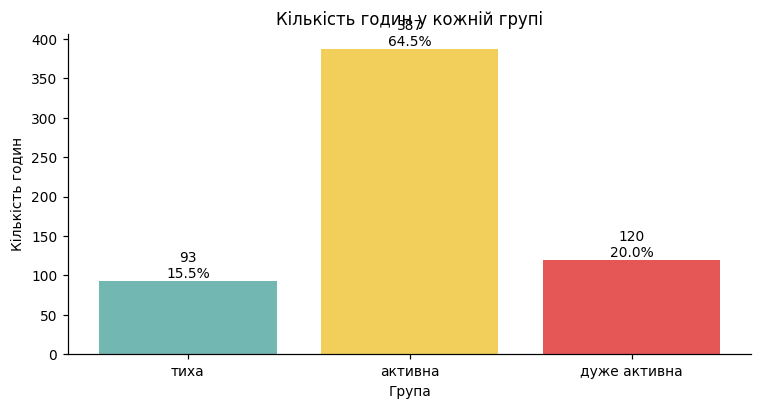

In [ ]:
counts = M['група'].value_counts().reindex(['тиха', 'активна', 'дуже активна'])
percent = counts / counts.sum() * 100

plt.figure(figsize=(7, 3.8))
bars = plt.bar(counts.index, counts.values, color=['#72b7b2', '#f2cf5b', '#e45756'])
plt.xlabel('Група')
plt.ylabel('Кількість годин')
plt.title('Кількість годин у кожній групі')

for i, (c, p) in enumerate(zip(counts.values, percent.values)):
    plt.text(i, c, f'{c}\n{p:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Висновок:** Розподіл за групами показує, яка частина всього періоду була спокійною, а яка припала на підвищену чи дуже високу активність; зазвичай тихих годин значно більше, а сильні події концентруються в невеликій частині спостережень.

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

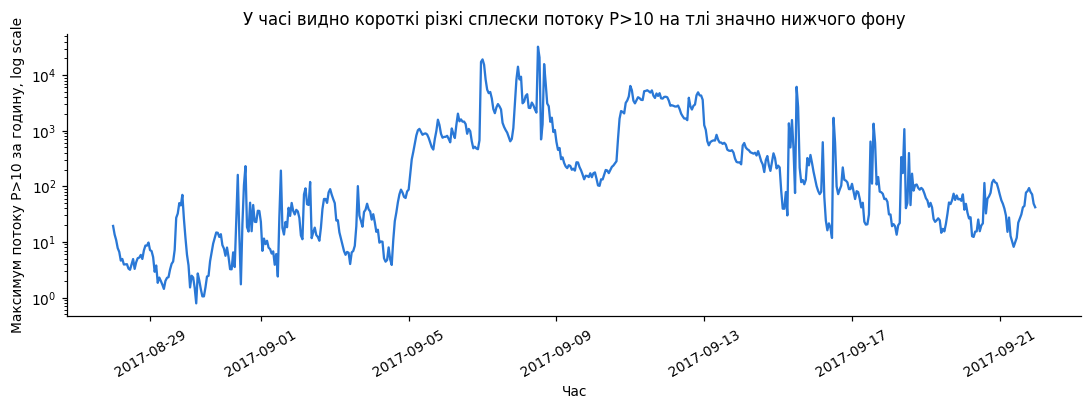

In [ ]:
plt.figure(figsize=(10, 3.8))
series = M[['ts', 'P>10_max']].dropna()

if (series['P>10_max'] > 0).all():
    plt.plot(series['ts'], series['P>10_max'], color='#2a78d6')
    plt.yscale('log')
    plt.ylabel('Максимум потоку P>10 за годину, log scale')
else:
    plt.plot(series['ts'], series['P>10_max'], color='#2a78d6')
    plt.ylabel('Максимум потоку P>10 за годину')

plt.xlabel('Час')
plt.title('У часі видно короткі різкі сплески потоку P>10 на тлі значно нижчого фону')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Висновок:** У часовому ряді максимуму `P>10` важливі не лише окремі пікові години, а й те, що вони різко виділяються на тлі значно нижчого фону, тому логарифмічна шкала робить структуру періоду читабельнішою.

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

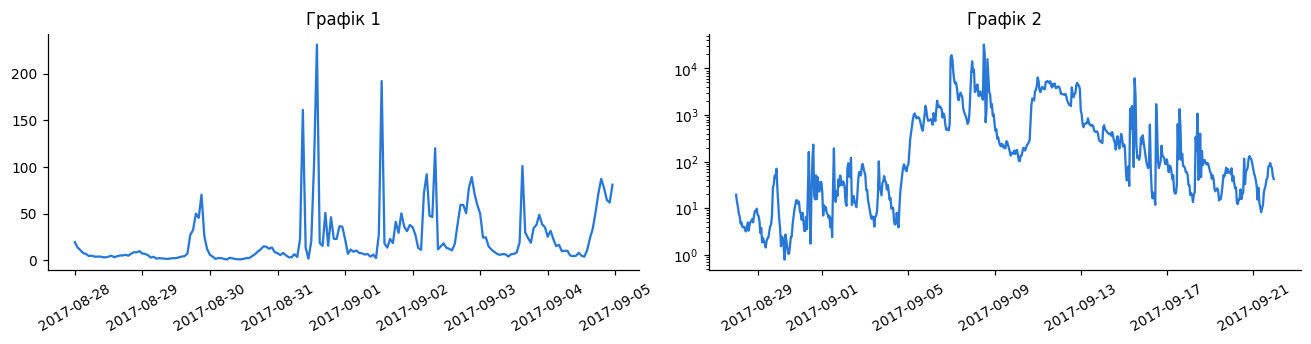

In [ ]:
СТОВПЕЦЬ = 'P>10_max'  # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. **Висновок з першого графіка:** якщо дивитися лише на перший графік, можна вирішити, що важлива активність зосереджена лише на початку періоду, а решта часу майже нічого не відбувається.

2. **Висновок з другого графіка:** якщо дивитися лише на другий графік, видно, що протягом усього періоду значення змінювалися в широкому діапазоні, а сильні сплески були частиною загальної картини, а не єдиною подією.

3. **Дві відмінності між ними:**  
   - на першому графіку показано лише коротке вікно часу (`2017-08-28` — `2017-09-05`), а на другому — весь період;  
   - на другому графіку вісь `y` логарифмічна (`set_yscale('log')`), а на першому — звичайна лінійна.

### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

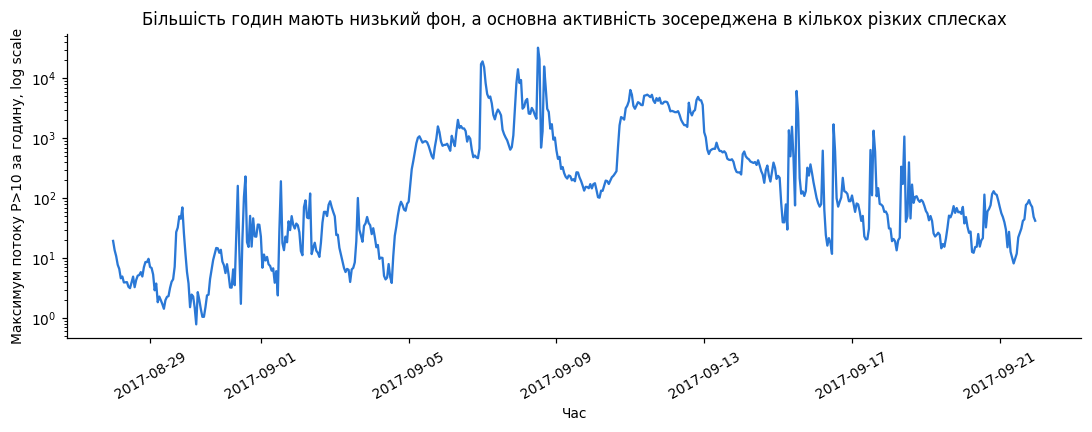

In [ ]:
plt.figure(figsize=(10, 4))
series = M[['ts', 'P>10_max']].dropna()
plt.plot(series['ts'], series['P>10_max'], color='#2a78d6')
plt.yscale('log')
plt.xlabel('Час')
plt.ylabel('Максимум потоку P>10 за годину, log scale')
plt.title('Більшість годин мають низький фон, а основна активність зосереджена в кількох різких сплесках')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Відповідь 6.2:** Я обрав графік за весь період у логарифмічній шкалі, бо він одночасно показує і часове розташування головних сплесків, і фонові значення між ними. На звичайній шкалі великі піки повністю пригнічують дрібніші зміни, а на короткому часовому вікні можна зробити хибний висновок про весь період.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** Розподіл погодинного потоку `P>5` є сильно асиметричним вправо: це видно з гістограми на етапі 5.1 і з того, що середнє помітно більше за медіану.

**Спостереження 2:** У часовому ряді `P>10_max` активність зосереджена в небагатьох різких сплесках, а більшість годин мають значно нижчий рівень; це видно на графіку 5 і в порівнянні графіків на етапі 6.

**Спостереження 3:** Навіть якщо між швидкістю та густиною сонячного вітру є певна тенденція, вона не обов’язково сильна; це видно з розсіювання точок і коефіцієнта кореляції на графіку 3.

### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [ ]:
rows_with_na = M.isna().any(axis=1).sum()
share_with_na = rows_with_na / len(M)

print('Рядків із хоча б одним пропуском:', rows_with_na)
print('Усього рядків:', len(M))
print('Частка:', share_with_na)
print('Частка у відсотках: %.2f%%' % (share_with_na * 100))

Рядків із хоча б одним пропуском: 1201
Усього рядків: 1201
Частка: 1.0
Частка у відсотках: 100.00%


**Відповідь 7.2:** Частка рядків, у яких є хоча б один пропуск, дорівнює `rows_with_na / len(M)`; це показує, яка частина погодинної таблиці є неповною після об’єднання трьох джерел із різною часовою сіткою та різними межами покриття.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [ ]:
ІНСТРУМЕНТИ_ШІ = 'ChatGPT'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'код, перевірено',
    'етап 3, паспорт даних і дивні значення':     'код, перевірено',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'текст, перероблено',
    'етапи 6–7, порівняння графіків і спостереження': 'текст, перероблено',
}

ЩО_ПЕРЕВІРЕНО = (
    'Я перевірив, що після розбору таблиць виконуються контрольні умови для довжин A, B і C, '
    'переглянув перші рядки кожної таблиці, звірив правильність формування datetime у 2017 році, '
    'перевірив, що від’ємні значення швидкості та густини замінюються на NaN, а також що після '
    'об’єднання таблиця M містить стовпець ts і стовпець «група». Окремо переглянув графіки, '
    'підписи осей, назви стовпців P>5_avg і P>10_max та перевірив, що код виконується зверху вниз.'
)

ПІДТВЕРДЖУЮ = True

In [ ]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Іваник Тарас Юрійович
інструменти:                                   ChatGPT
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    код, перевірено
етап 3, паспорт даних і дивні значення:        код, перевірено
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                текст, перероблено
етапи 6–7, порівняння графіків і спостереження: текст, перероблено
------------------------------------------------------------------------------
перевірено автором:
Я перевірив, що після розбору таблиць виконуються контрольні умови для довжин A, B і C, переглянув перші рядки кожної таблиці, звірив правильність формування datetime у 2017 році, перевірив, що від’ємні значення швидкості та густини замінюються на NaN, а також що після

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [ ]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (1201, 21)


In [ ]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
НЕ ОК  таблиці об’єднано
OK     стовпець «група» є
НЕ ОК  усі дати у 2017 році
OK     декларацію заповнено
